In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

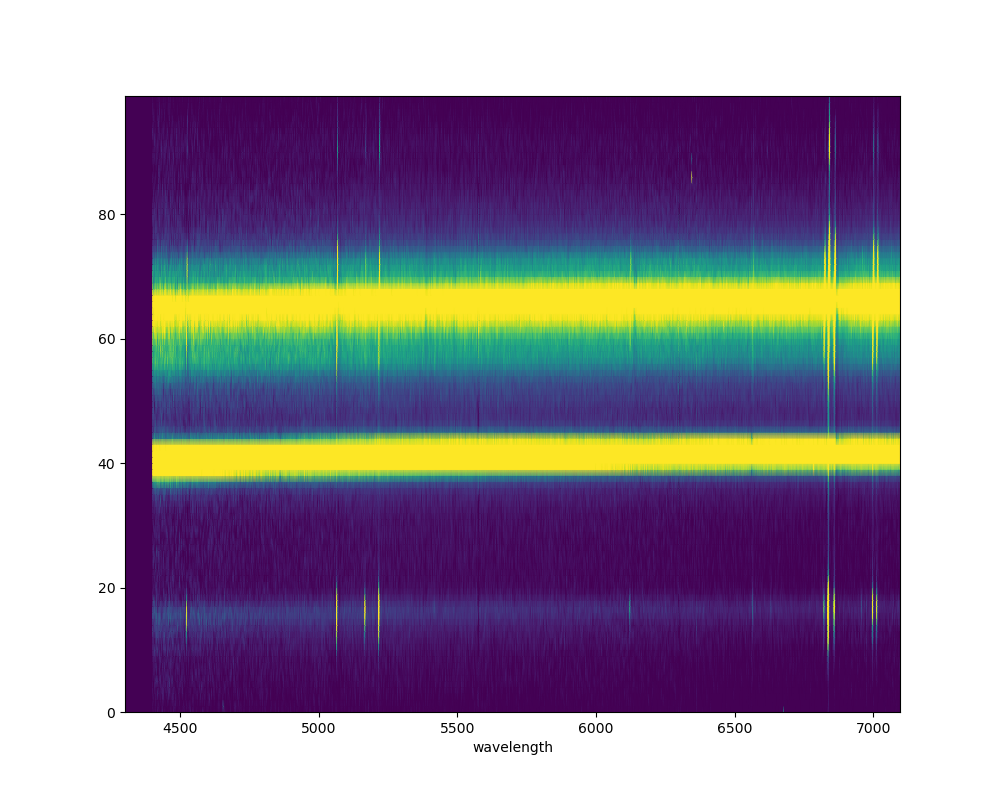

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.00391516 1.0803587  1.00353273 1.00194585 1.0715137 ]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

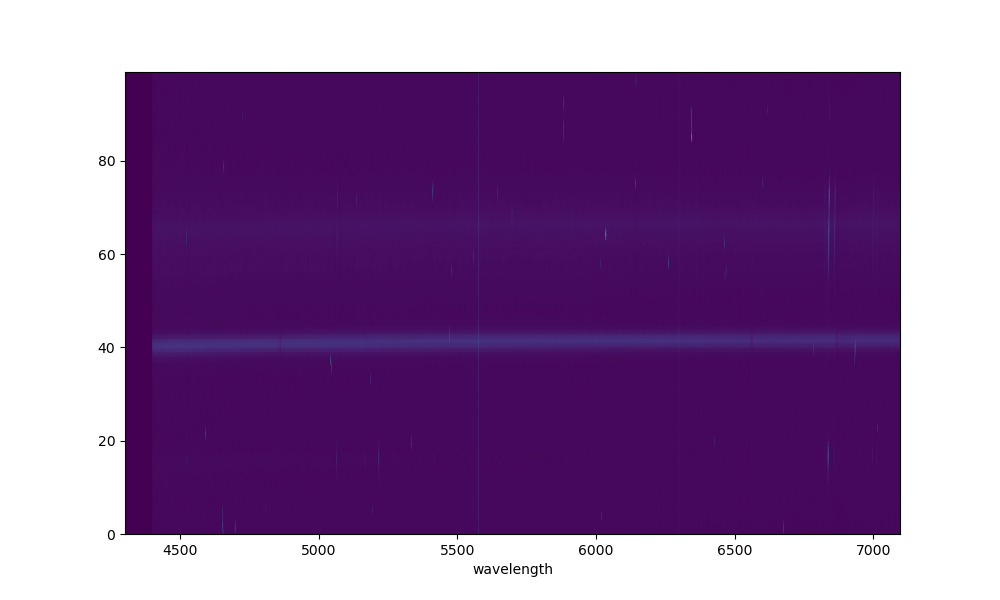

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[49:149, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

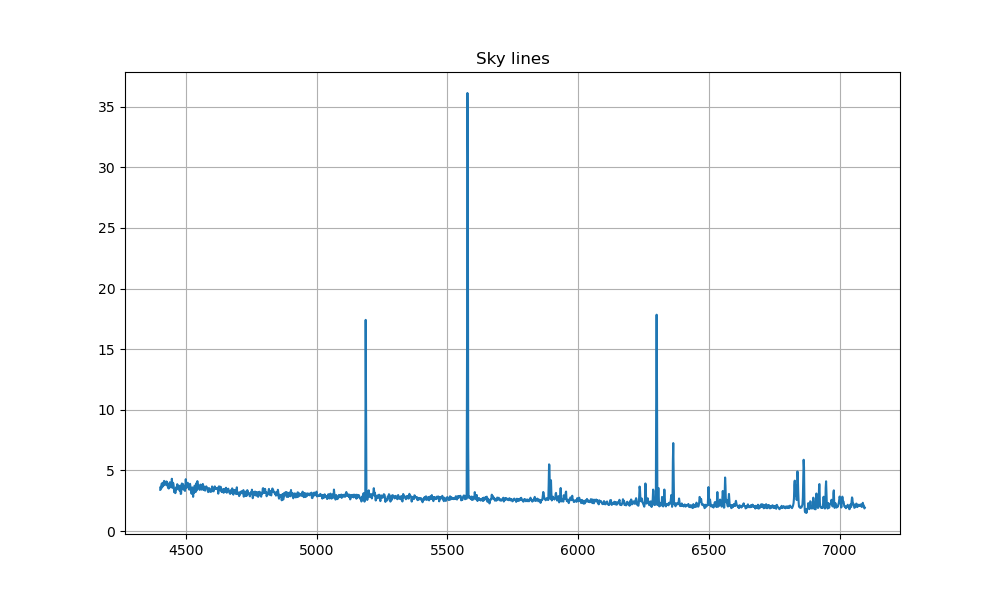

In [8]:
mask_sky = (y > 25)*(y < 35)
mask_wv = wv > 4400
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

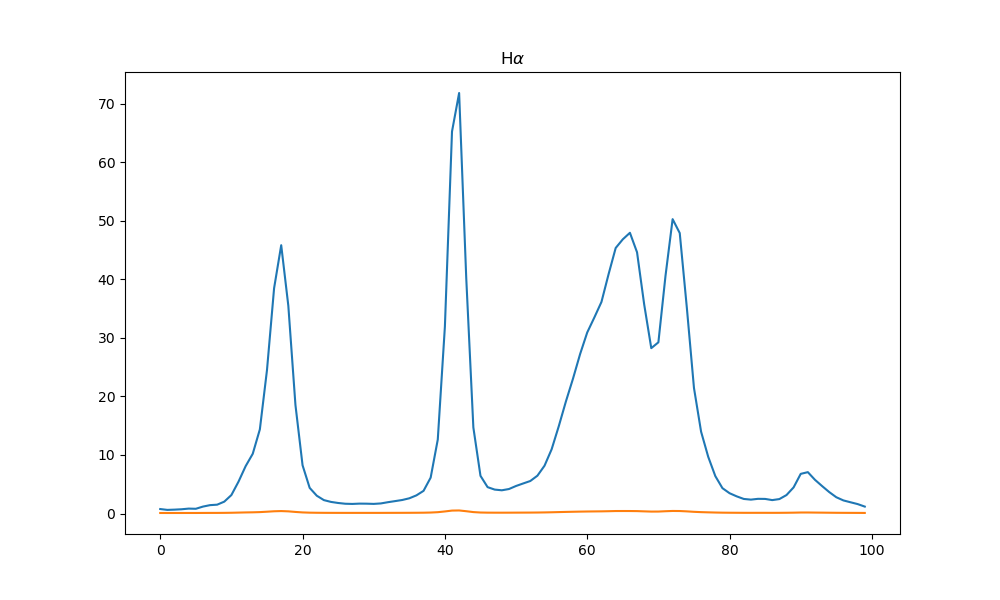

In [22]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [24]:
n_component = 6

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 83)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 83)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [13]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 82604.92450208859
differential_evolution step 2: f(x)= 37991.57368797776
differential_evolution step 3: f(x)= 37991.57368797776
differential_evolution step 4: f(x)= 33936.151800351974
differential_evolution step 5: f(x)= 33936.151800351974
differential_evolution step 6: f(x)= 22012.77381643004
differential_evolution step 7: f(x)= 15065.844812077417
differential_evolution step 8: f(x)= 15065.844812077417
differential_evolution step 9: f(x)= 14788.266098388145
differential_evolution step 10: f(x)= 14788.266098388145
differential_evolution step 11: f(x)= 14788.266098388145
differential_evolution step 12: f(x)= 12852.827458547185
differential_evolution step 13: f(x)= 12852.827458547185
differential_evolution step 14: f(x)= 12852.827458547185
differential_evolution step 15: f(x)= 12852.827458547185
differential_evolution step 16: f(x)= 12852.827458547185
differential_evolution step 17: f(x)= 11549.712084909432
differential_evolution step 18: f(x)= 9232.2

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15548\1217429467.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=1.3895, r_e=11.1395, n=2.7466, x_0=16.7736
Sérsic 2: I_e=2.8586, r_e=4.6726, n=3.0565, x_0=41.6152
Sérsic 3: I_e=6.5530, r_e=7.0526, n=0.8723, x_0=60.2908
Sérsic 4: I_e=9.3926, r_e=4.5076, n=0.9653, x_0=65.6000
Sérsic 5: I_e=4.7449, r_e=5.5229, n=1.7078, x_0=72.5763
Sérsic 6: I_e=0.9405, r_e=6.4658, n=1.4161, x_0=91.2852
Chi quadro minimo: 99.80199379811201
False


Sérsic 1: I_e=1.3895, r_e=11.1395, n=2.7466, x_0=16.7736
Sérsic 2: I_e=2.8586, r_e=4.6726, n=3.0565, x_0=41.6152
Sérsic 3: I_e=6.5530, r_e=7.0526, n=0.8723, x_0=60.2908
Sérsic 4: I_e=9.3926, r_e=4.5076, n=0.9653, x_0=65.6000
Sérsic 5: I_e=4.7449, r_e=5.5229, n=1.7078, x_0=72.5763
Sérsic 6: I_e=0.9405, r_e=6.4658, n=1.4161, x_0=91.2852


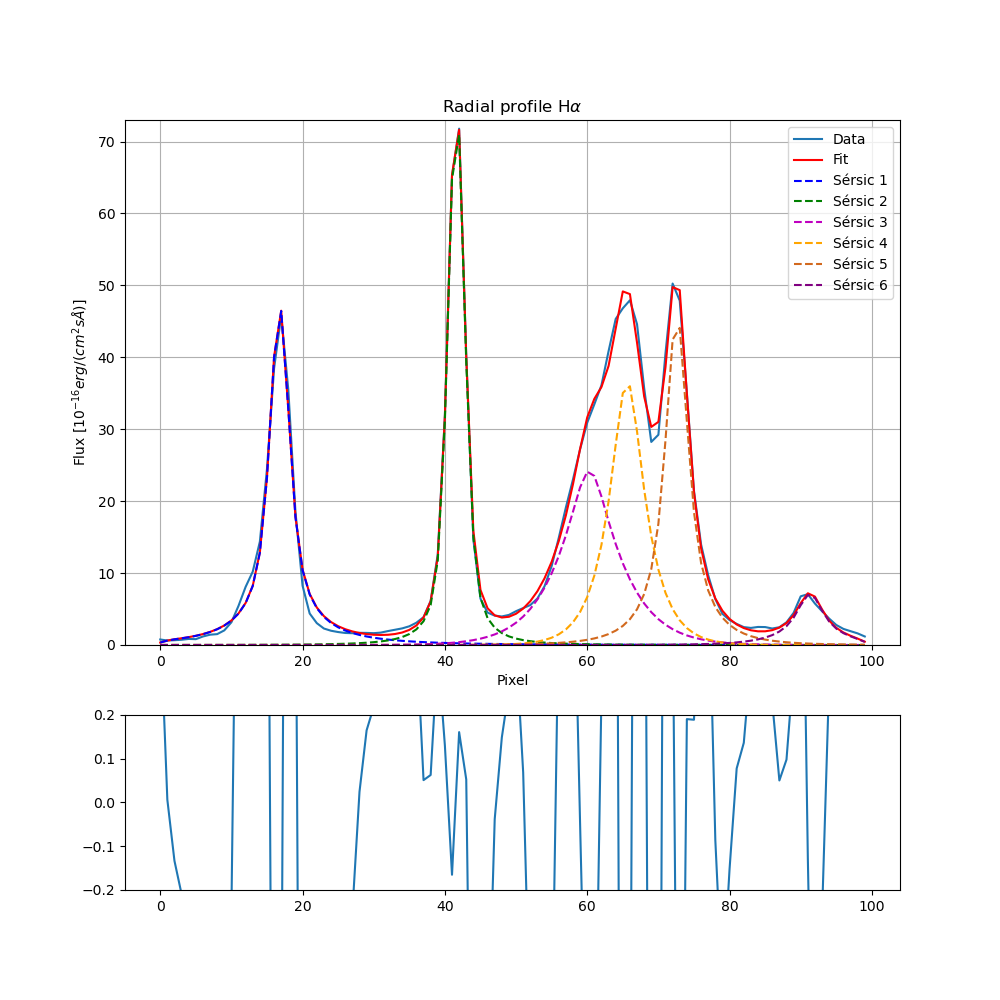

In [14]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [15]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.3189, r_e=10.9768, n=2.8420, x_0=16.6268
Sérsic 2: I_e=2.8302, r_e=4.6566, n=3.0356, x_0=41.6152
Sérsic 3: I_e=6.5184, r_e=6.9821, n=0.8845, x_0=60.3210
Sérsic 4: I_e=9.3911, r_e=4.4883, n=0.9674, x_0=65.5906
Sérsic 5: I_e=4.7418, r_e=5.5578, n=1.7061, x_0=72.5908
Sérsic 6: I_e=0.9772, r_e=6.7674, n=1.3700, x_0=91.2633
[6.74820163e-01 3.73386008e+00 4.43089868e-01 5.62109211e-02
 3.45875365e+00 3.15006333e+00 2.61489932e+00 6.92753325e-04
 4.96700416e+00 1.03431630e+00 1.95011766e-01 6.63271074e-01
 1.46275560e+01 8.01030236e+00 1.05594452e+00 3.08894528e-01
 2.91029997e+00 2.04238202e+00 4.67355908e-01 1.69903565e-01
 1.01696684e+00 5.52055102e+00 7.23355805e-01 2.06625476e-01]
2.7559339914120287


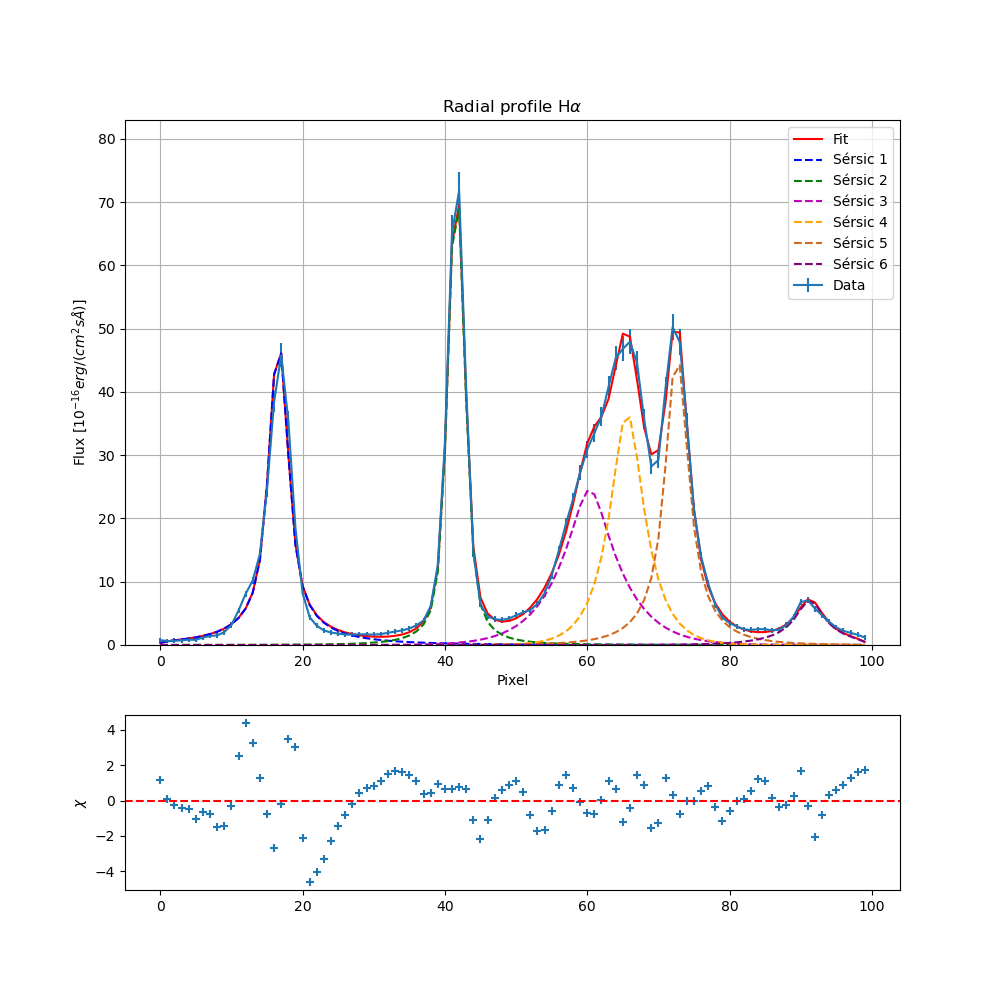

In [25]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [17]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 10),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),

     (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[5]-seeing[-1]/2, x_0_HA[5]+seeing[-1]/2),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

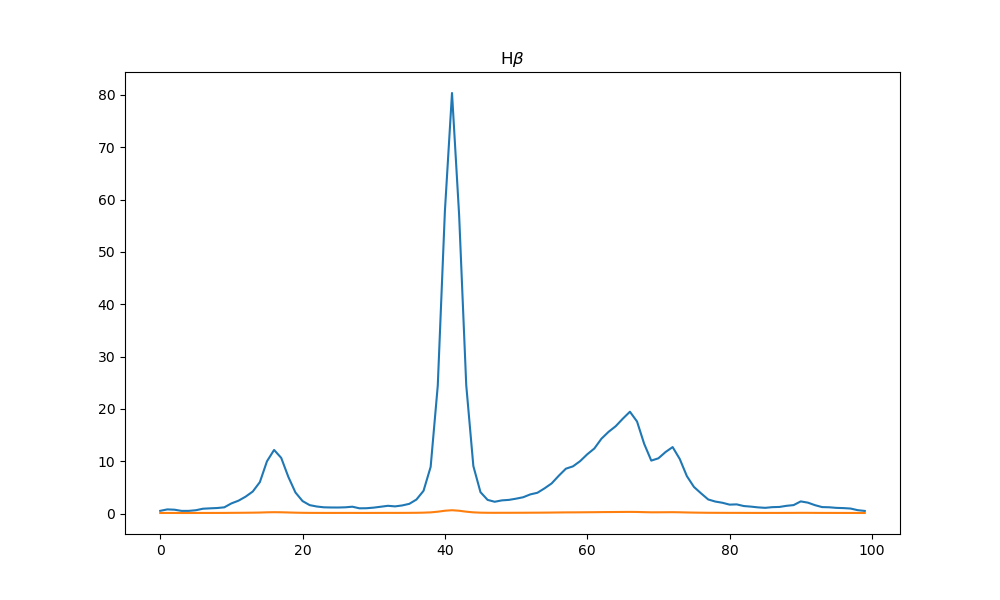

In [18]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [19]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 323456.5596560366
differential_evolution step 2: f(x)= 222419.06346441415
differential_evolution step 3: f(x)= 52270.59671511459
differential_evolution step 4: f(x)= 23600.19612724036
differential_evolution step 5: f(x)= 20710.50679448919
differential_evolution step 6: f(x)= 15968.341328610562
differential_evolution step 7: f(x)= 15968.341328610562
differential_evolution step 8: f(x)= 12109.022043524918
differential_evolution step 9: f(x)= 12109.022043524918
differential_evolution step 10: f(x)= 5091.2840209888855
differential_evolution step 11: f(x)= 5091.2840209888855
differential_evolution step 12: f(x)= 3663.5491181972834
differential_evolution step 13: f(x)= 3663.5491181972834
differential_evolution step 14: f(x)= 2885.7607846160035
differential_evolution step 15: f(x)= 1916.24290239624
differential_evolution step 16: f(x)= 1916.24290239624
differential_evolution step 17: f(x)= 1916.24290239624
differential_evolution step 18: f(x)= 1916.2429023

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15548\1217429467.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.9071, r_e=7.8315, n=1.9183, x_0=16.0420
Sérsic 2: I_e=2.9775, r_e=4.0477, n=3.4782, x_0=40.9788
Sérsic 3: I_e=3.0708, r_e=5.7541, n=0.5123, x_0=60.7001
Sérsic 4: I_e=1.5865, r_e=14.5738, n=1.4807, x_0=65.9010
Sérsic 5: I_e=6.8512, r_e=1.0359, n=0.2692, x_0=72.2587
Sérsic 6: I_e=0.1592, r_e=11.4326, n=1.5093, x_0=90.9406
Chi quadro minimo: 10.748932411986196
False


Sérsic 1: I_e=0.9071, r_e=7.8315, n=1.9183, x_0=16.0420
Sérsic 2: I_e=2.9775, r_e=4.0477, n=3.4782, x_0=40.9788
Sérsic 3: I_e=3.0708, r_e=5.7541, n=0.5123, x_0=60.7001
Sérsic 4: I_e=1.5865, r_e=14.5738, n=1.4807, x_0=65.9010
Sérsic 5: I_e=6.8512, r_e=1.0359, n=0.2692, x_0=72.2587
Sérsic 6: I_e=0.1592, r_e=11.4326, n=1.5093, x_0=90.9406


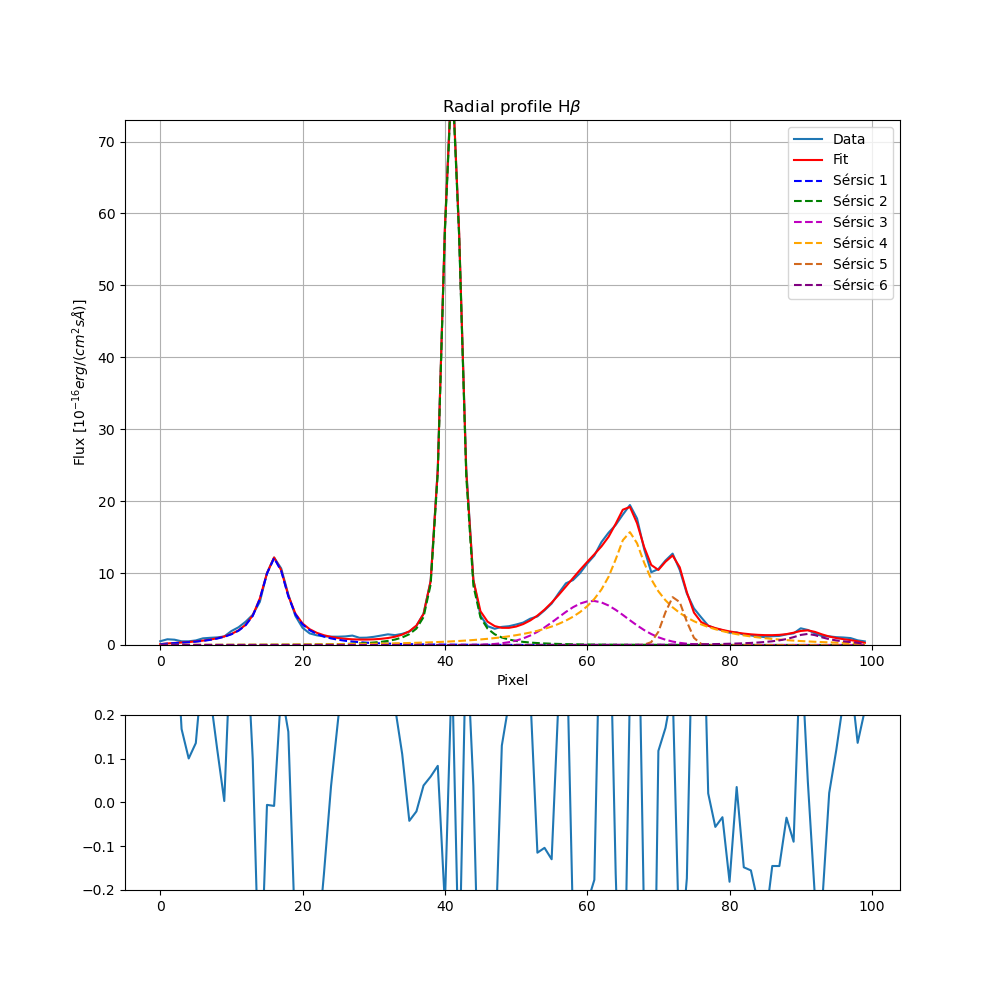

In [20]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [21]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB) #, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2091, r_e=21.9956, n=3.0468, x_0=16.0320
Sérsic 2: I_e=3.8727, r_e=3.3915, n=3.2544, x_0=40.9784
Sérsic 3: I_e=3.9010, r_e=7.0775, n=0.6023, x_0=61.7772
Sérsic 4: I_e=0.4138, r_e=22.4395, n=2.3024, x_0=65.9009
Sérsic 5: I_e=0.7560, r_e=4.4283, n=1.9294, x_0=72.1799
Sérsic 6: I_e=0.0212, r_e=105.5748, n=2.7594, x_0=90.5581
[2.47942580e-01 2.19463995e+01 8.54921494e-01 4.46946943e-02
 2.25212573e+00 1.19531560e+00 5.90350670e-01 1.47361083e-02
 1.62361275e+00 8.55664049e-01 9.48966791e-02 1.96882846e+00
 1.16967594e+00 4.47074260e+01 1.76807863e+00 9.77588672e-02
 1.37964771e+00 6.08905588e+00 1.38578036e+00 1.10124299e-01
 3.30851580e-01 1.51626138e+03 1.06420840e+01 8.66103280e-02]
0.4221875539228755


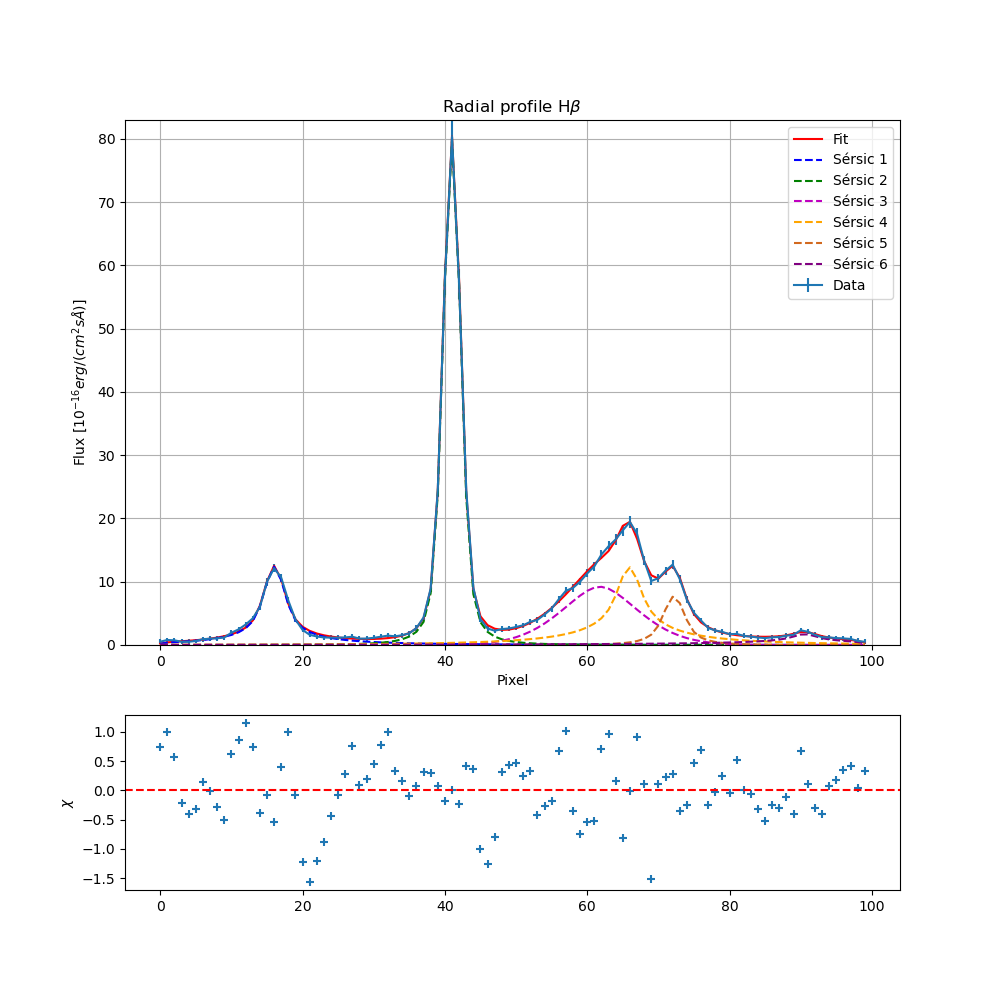

In [26]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

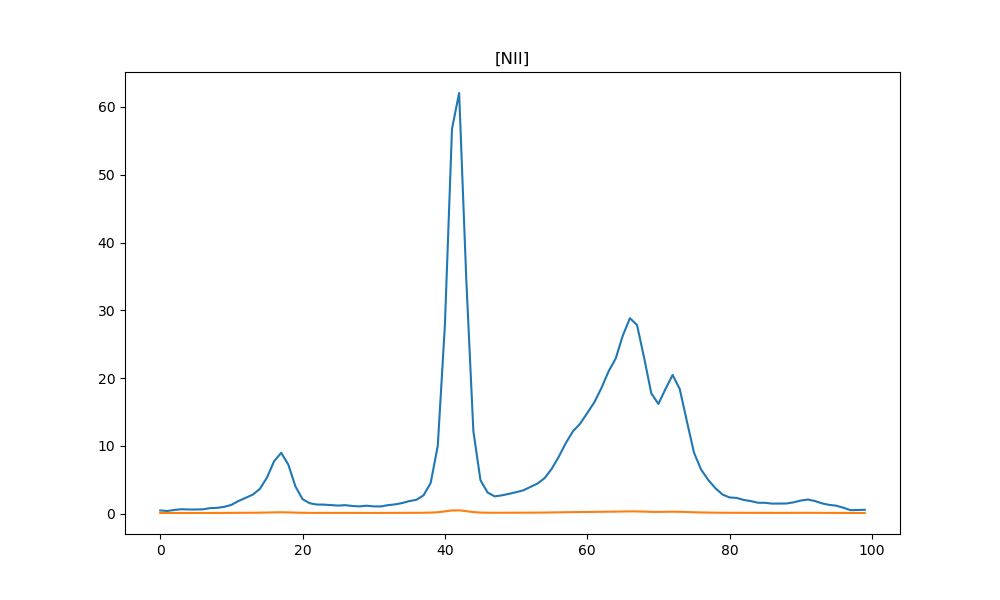

In [27]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [28]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 150997.70744721615
differential_evolution step 2: f(x)= 58902.022687333665
differential_evolution step 3: f(x)= 7463.930762054871
differential_evolution step 4: f(x)= 7463.930762054871
differential_evolution step 5: f(x)= 7463.930762054871
differential_evolution step 6: f(x)= 7463.930762054871
differential_evolution step 7: f(x)= 7463.930762054871
differential_evolution step 8: f(x)= 7463.930762054871
differential_evolution step 9: f(x)= 7463.930762054871
differential_evolution step 10: f(x)= 7463.930762054871
differential_evolution step 11: f(x)= 7463.930762054871
differential_evolution step 12: f(x)= 4803.021179351685
differential_evolution step 13: f(x)= 4803.021179351685
differential_evolution step 14: f(x)= 3420.137259741672
differential_evolution step 15: f(x)= 3420.137259741672
differential_evolution step 16: f(x)= 3420.137259741672
differential_evolution step 17: f(x)= 3420.137259741672
differential_evolution step 18: f(x)= 3158.305861926521

Sérsic 1: I_e=0.4595, r_e=9.8291, n=2.1409, x_0=16.7104
Sérsic 2: I_e=10.0000, r_e=1.7489, n=2.0377, x_0=41.6011
Sérsic 3: I_e=0.3243, r_e=46.0134, n=1.9589, x_0=59.3210
Sérsic 4: I_e=5.6256, r_e=7.2655, n=0.9982, x_0=65.9691
Sérsic 5: I_e=1.1042, r_e=3.7821, n=2.0369, x_0=72.5875
Sérsic 6: I_e=0.2494, r_e=6.1754, n=1.1464, x_0=91.0886


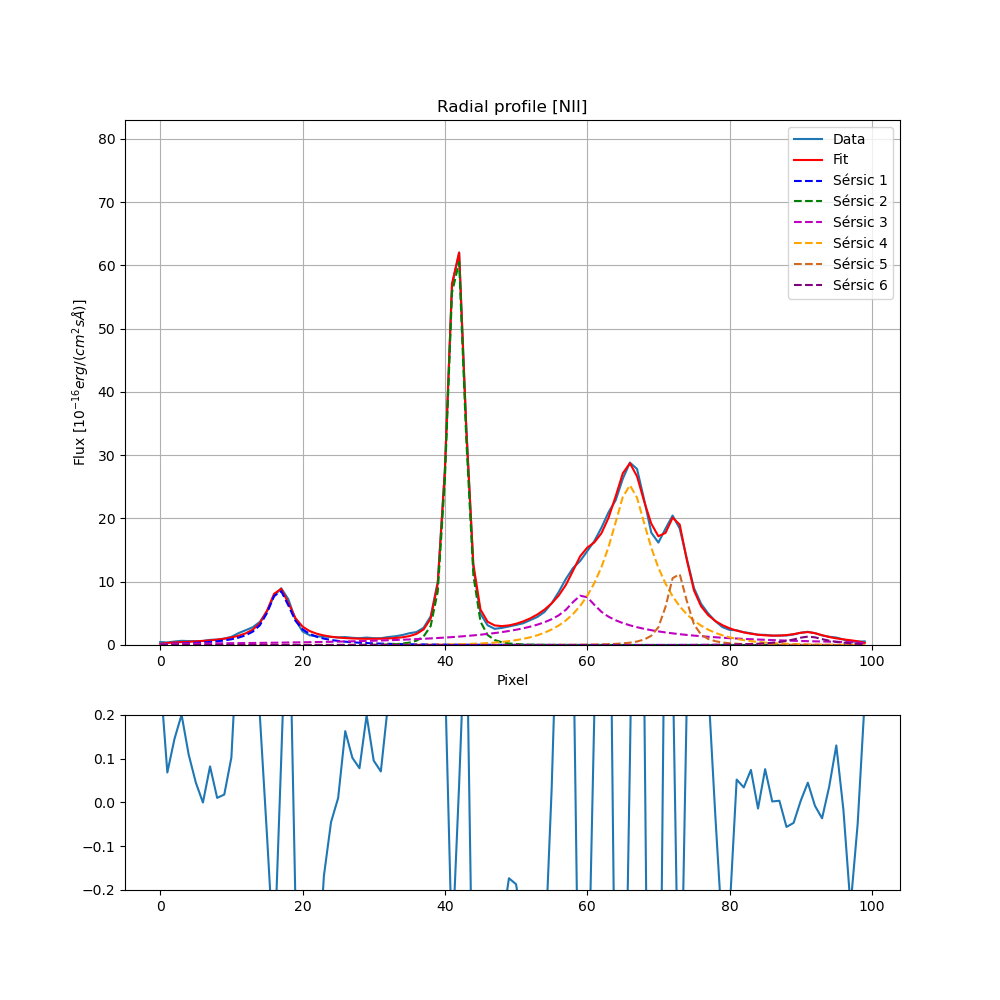

In [29]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [31]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.4250, r_e=10.0000, n=2.2174, x_0=16.6725
Sérsic 2: I_e=10.0000, r_e=1.7114, n=2.0724, x_0=41.5758
Sérsic 3: I_e=0.3146, r_e=50.0000, n=2.0113, x_0=59.3210
Sérsic 4: I_e=5.9837, r_e=6.5753, n=0.9492, x_0=65.8573
Sérsic 5: I_e=1.1306, r_e=4.6281, n=1.9246, x_0=72.5955
Sérsic 6: I_e=0.1776, r_e=7.6784, n=1.3666, x_0=91.0397
[4.79644333e-01 9.50438260e+00 8.09218037e-01 6.76596939e-02
 3.77833357e+00 3.41197320e-01 3.87308982e-01 1.80021193e-02
 6.80825797e-01 8.14548249e+01 1.11420508e+00 2.80329555e-01
 1.46890379e+00 3.17316824e+00 1.94543037e-01 1.05954414e-01
 2.26940480e+00 9.12312129e+00 1.43038550e+00 9.24895039e-02
 4.49880026e-01 1.75234854e+01 1.71500550e+00 4.59928308e-01]
0.5884695470086783


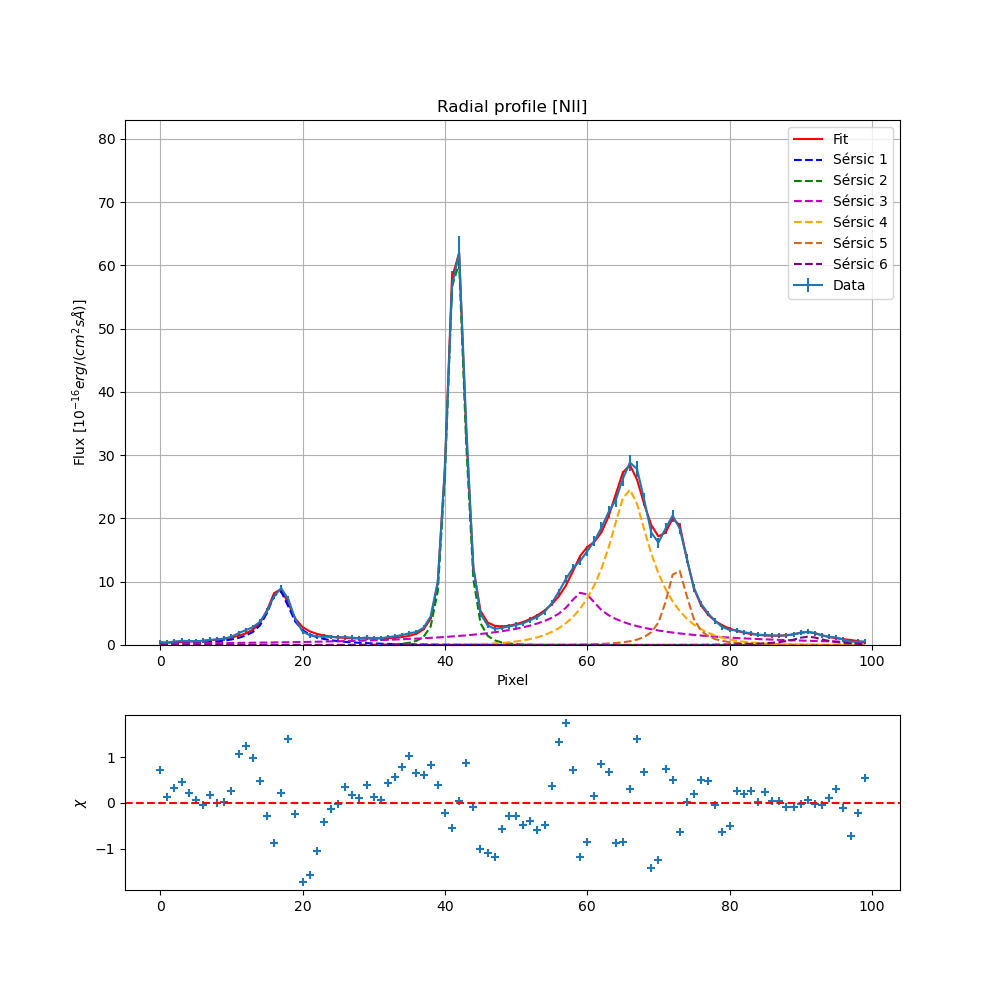

In [32]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

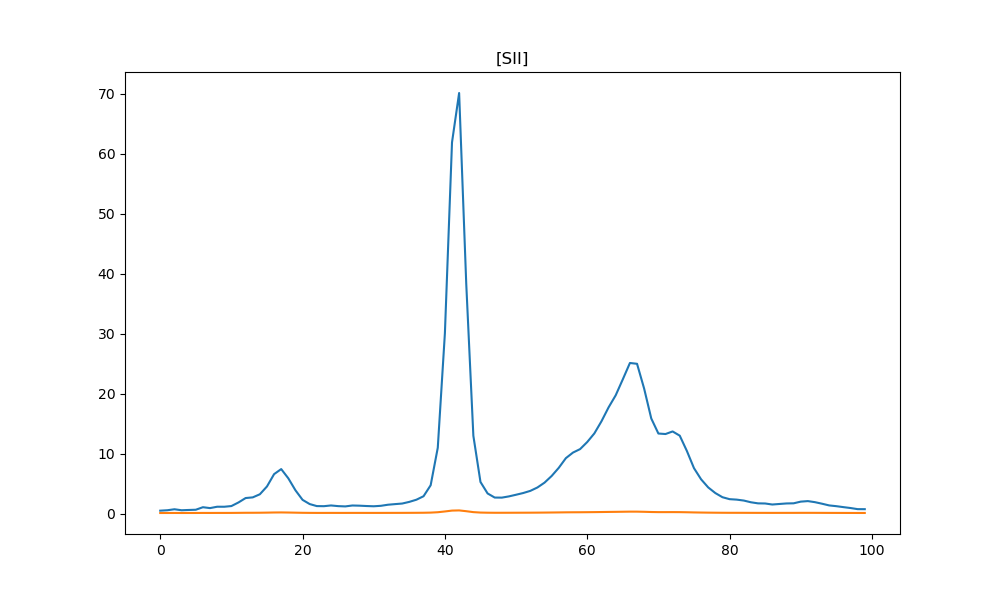

In [33]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [34]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 265380.1601721428
differential_evolution step 2: f(x)= 73712.52382560934
differential_evolution step 3: f(x)= 28924.908435117006
differential_evolution step 4: f(x)= 28924.908435117006
differential_evolution step 5: f(x)= 13264.027587104301
differential_evolution step 6: f(x)= 8231.122828308138
differential_evolution step 7: f(x)= 4251.306711520071
differential_evolution step 8: f(x)= 3236.4273108164725
differential_evolution step 9: f(x)= 3236.4273108164725
differential_evolution step 10: f(x)= 2696.1405592800015
differential_evolution step 11: f(x)= 2696.1405592800015
differential_evolution step 12: f(x)= 2696.1405592800015
differential_evolution step 13: f(x)= 2696.1405592800015
differential_evolution step 14: f(x)= 1839.773963326339
differential_evolution step 15: f(x)= 1839.773963326339
differential_evolution step 16: f(x)= 1839.773963326339
differential_evolution step 17: f(x)= 1839.773963326339
differential_evolution step 18: f(x)= 1839.77396

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15548\1698181913.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.6085, r_e=10.0000, n=1.6720, x_0=16.6857
Sérsic 2: I_e=3.6215, r_e=3.4228, n=3.0905, x_0=41.6242
Sérsic 3: I_e=3.4774, r_e=5.7906, n=0.4373, x_0=61.1757
Sérsic 4: I_e=1.8373, r_e=15.6919, n=1.5873, x_0=66.4299
Sérsic 5: I_e=1.4105, r_e=2.6581, n=1.2892, x_0=72.8537
Sérsic 6: I_e=0.1275, r_e=12.6426, n=1.5547, x_0=91.6536
Chi quadro minimo: 13.117195774867534
False


Sérsic 1: I_e=0.6085, r_e=10.0000, n=1.6720, x_0=16.6857
Sérsic 2: I_e=3.6215, r_e=3.4228, n=3.0905, x_0=41.6242
Sérsic 3: I_e=3.4774, r_e=5.7906, n=0.4373, x_0=61.1757
Sérsic 4: I_e=1.8373, r_e=15.6919, n=1.5873, x_0=66.4299
Sérsic 5: I_e=1.4105, r_e=2.6581, n=1.2892, x_0=72.8537
Sérsic 6: I_e=0.1275, r_e=12.6426, n=1.5547, x_0=91.6536


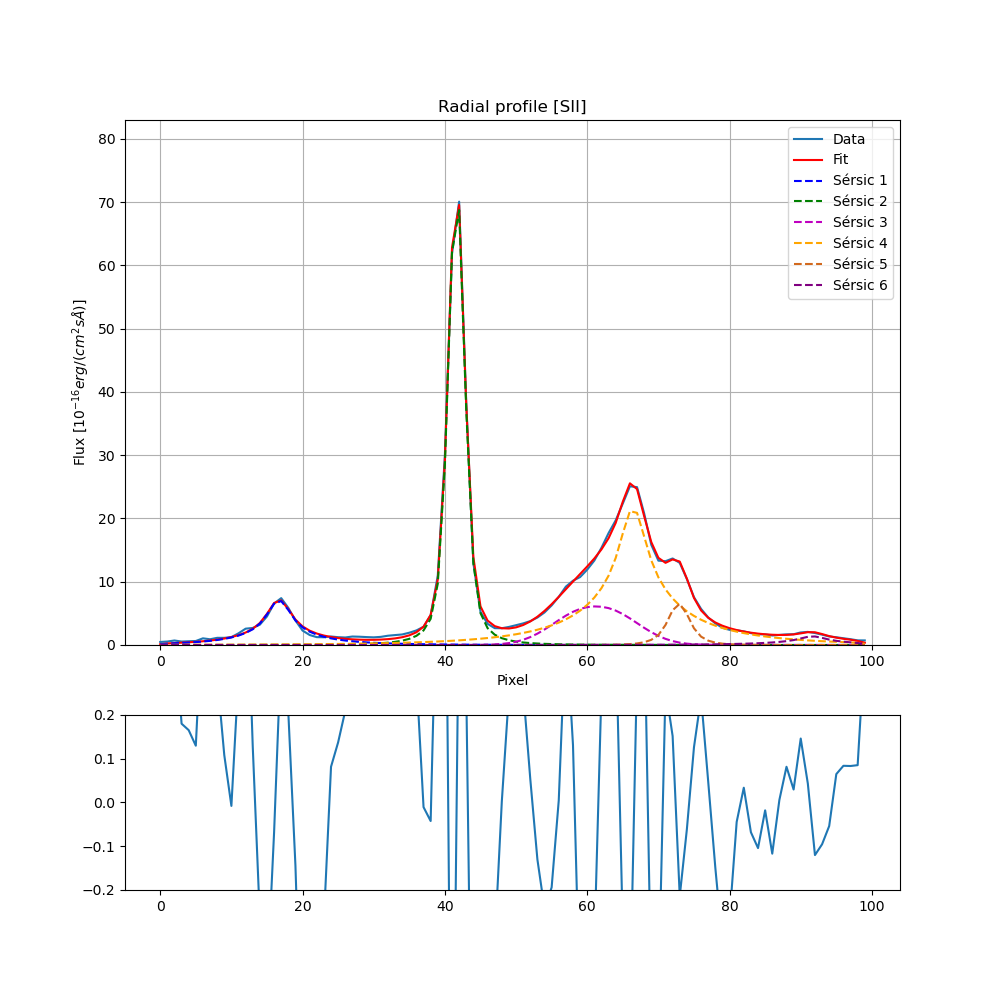

In [35]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [36]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5277, r_e=10.0000, n=1.7856, x_0=16.6362
Sérsic 2: I_e=2.4995, r_e=3.9670, n=3.5749, x_0=41.5833
Sérsic 3: I_e=3.7766, r_e=5.5230, n=0.4476, x_0=61.3210
Sérsic 4: I_e=0.8055, r_e=27.9262, n=2.1522, x_0=66.4158
Sérsic 5: I_e=2.6985, r_e=2.3088, n=0.7828, x_0=72.6949
Sérsic 6: I_e=0.3420, r_e=3.6967, n=0.7911, x_0=91.5461
[5.14940171e-01 7.91882337e+00 8.60365362e-01 4.11335439e-02
 2.00475809e+00 1.97032788e+00 8.07424835e-01 1.63315973e-02
 1.77941281e+00 1.20215977e+00 1.11394837e-01 2.56637413e+00
 1.35722705e+00 3.29208375e+01 9.60480606e-01 8.90406708e-02
 1.26233182e+00 8.10296869e-01 3.65623168e-01 1.69672486e-01
 4.91535969e-01 5.46732598e+00 1.08758920e+00 5.53758544e-01]
0.5303275597211341


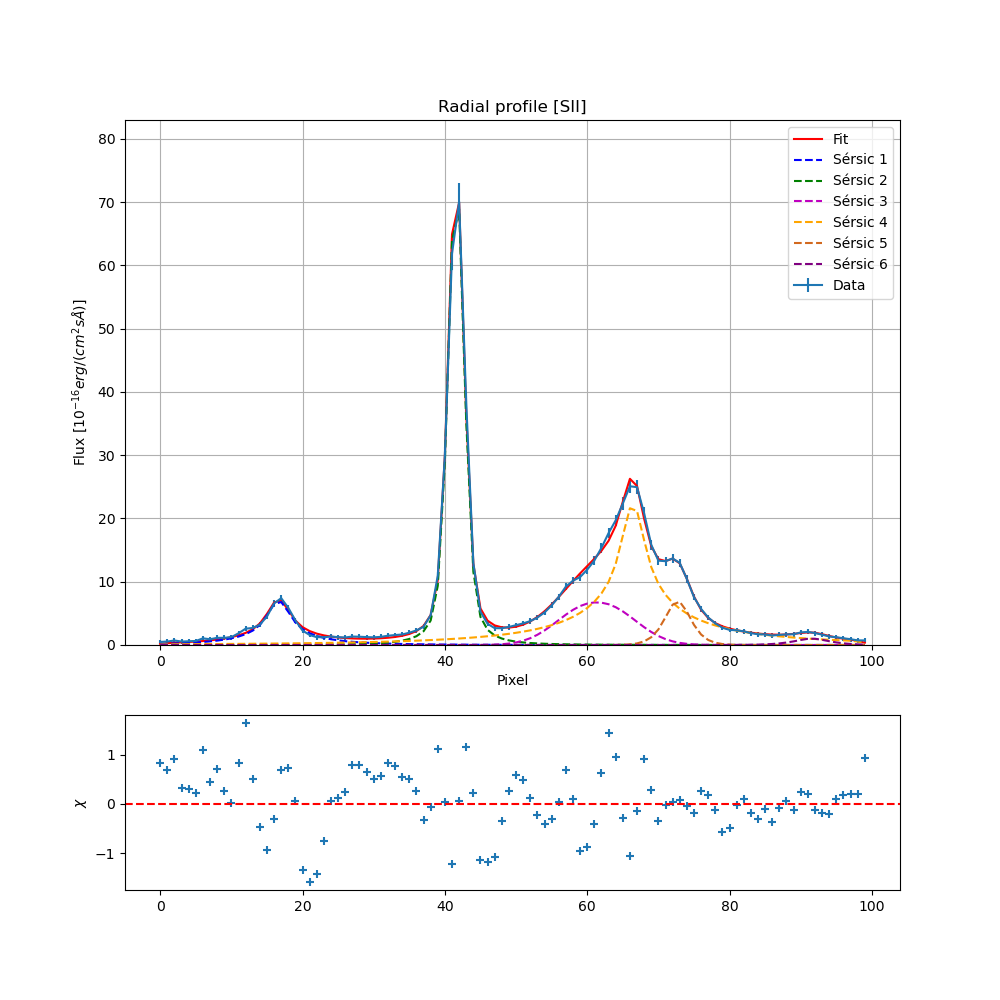

In [37]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

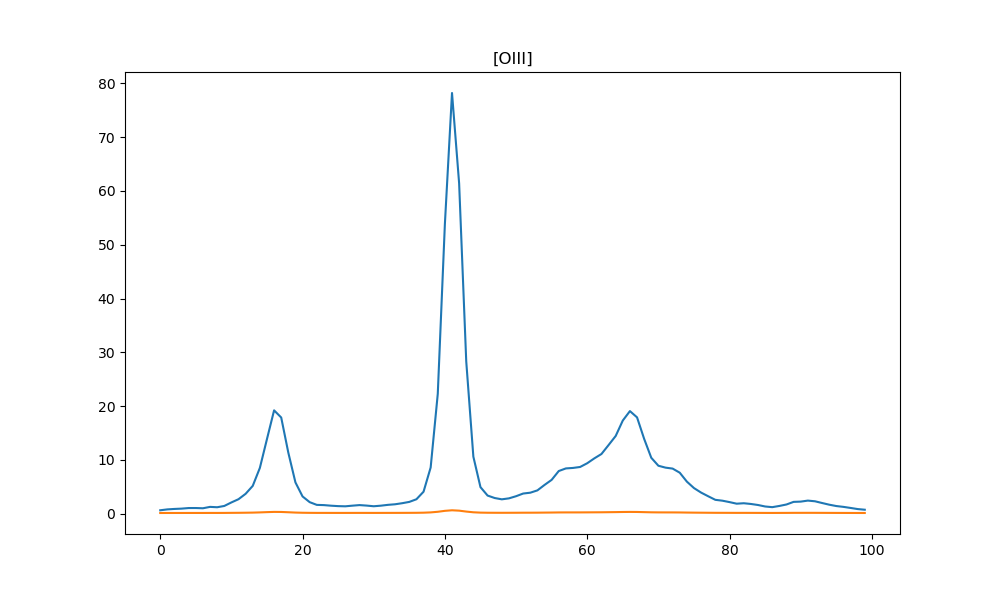

In [38]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [39]:
# Bounds:
bounds =bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 131192.0403388675
differential_evolution step 2: f(x)= 72529.1770054114
differential_evolution step 3: f(x)= 69252.86742158956
differential_evolution step 4: f(x)= 69252.86742158956
differential_evolution step 5: f(x)= 18007.967471930195
differential_evolution step 6: f(x)= 18007.967471930195
differential_evolution step 7: f(x)= 18007.967471930195
differential_evolution step 8: f(x)= 18007.967471930195
differential_evolution step 9: f(x)= 18007.967471930195
differential_evolution step 10: f(x)= 18007.967471930195
differential_evolution step 11: f(x)= 4327.626986337958
differential_evolution step 12: f(x)= 4327.626986337958
differential_evolution step 13: f(x)= 4327.626986337958
differential_evolution step 14: f(x)= 4327.626986337958
differential_evolution step 15: f(x)= 4327.626986337958
differential_evolution step 16: f(x)= 3757.0374890138705
differential_evolution step 17: f(x)= 3757.0374890138705
differential_evolution step 18: f(x)= 3757.0374890

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15548\1698181913.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.9136, r_e=8.5600, n=2.4134, x_0=16.2349
Sérsic 2: I_e=1.4322, r_e=7.0615, n=3.9830, x_0=41.1008
Sérsic 3: I_e=3.9824, r_e=5.9863, n=0.3811, x_0=60.0680
Sérsic 4: I_e=1.6045, r_e=5.9515, n=1.5118, x_0=66.1366
Sérsic 5: I_e=0.3954, r_e=33.0200, n=1.6539, x_0=72.0753
Sérsic 6: I_e=3.7538, r_e=0.1488, n=1.3851, x_0=91.3245
Chi quadro minimo: 16.65650169002939
False


Sérsic 1: I_e=0.9136, r_e=8.5600, n=2.4134, x_0=16.2349
Sérsic 2: I_e=1.4322, r_e=7.0615, n=3.9830, x_0=41.1008
Sérsic 3: I_e=3.9824, r_e=5.9863, n=0.3811, x_0=60.0680
Sérsic 4: I_e=1.6045, r_e=5.9515, n=1.5118, x_0=66.1366
Sérsic 5: I_e=0.3954, r_e=33.0200, n=1.6539, x_0=72.0753
Sérsic 6: I_e=3.7538, r_e=0.1488, n=1.3851, x_0=91.3245


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15548\1698181913.py:70: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


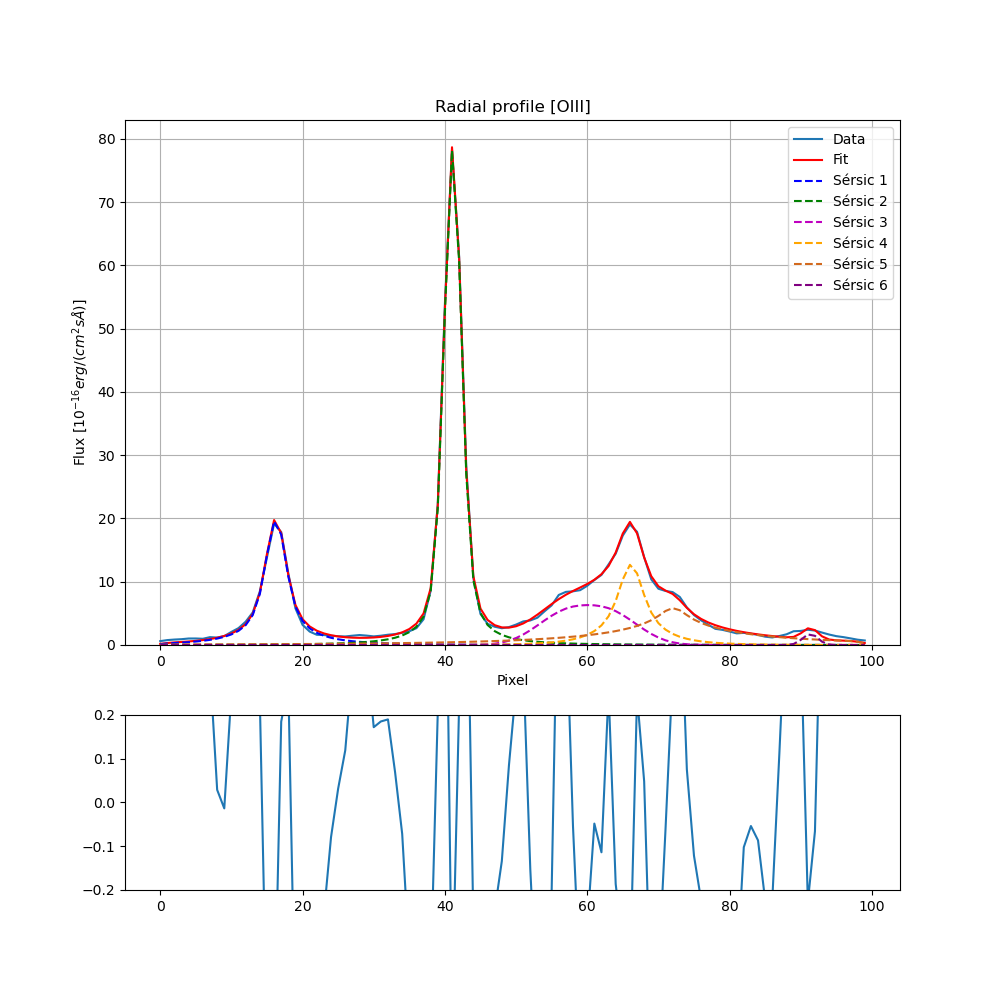

In [40]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [41]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.7088, r_e=9.9966, n=2.6111, x_0=16.1944
Sérsic 2: I_e=1.5180, r_e=6.3344, n=4.1031, x_0=41.1055
Sérsic 3: I_e=4.1592, r_e=6.2314, n=0.4372, x_0=60.0832
Sérsic 4: I_e=3.4954, r_e=3.0743, n=0.9876, x_0=66.1766
Sérsic 5: I_e=0.2068, r_e=49.2580, n=2.1956, x_0=72.3376
Sérsic 6: I_e=0.6437, r_e=3.4784, n=0.6343, x_0=91.6626
[5.06144743e-01 5.50445062e+00 5.52386427e-01 3.63424407e-02
 1.26770021e+00 3.38108025e+00 8.26413947e-01 1.68215496e-02
 3.53322900e+00 3.23773238e+00 2.16483358e-01 7.00318253e+00
 2.31293788e+00 4.79257151e+00 5.69763401e-01 9.82971724e-02
 5.43829999e-01 1.10032656e+02 1.87976047e+00 3.08068484e-02
 4.55470367e-01 2.43784272e+00 5.54533121e-01 4.03801755e-01]
0.5424282833157068


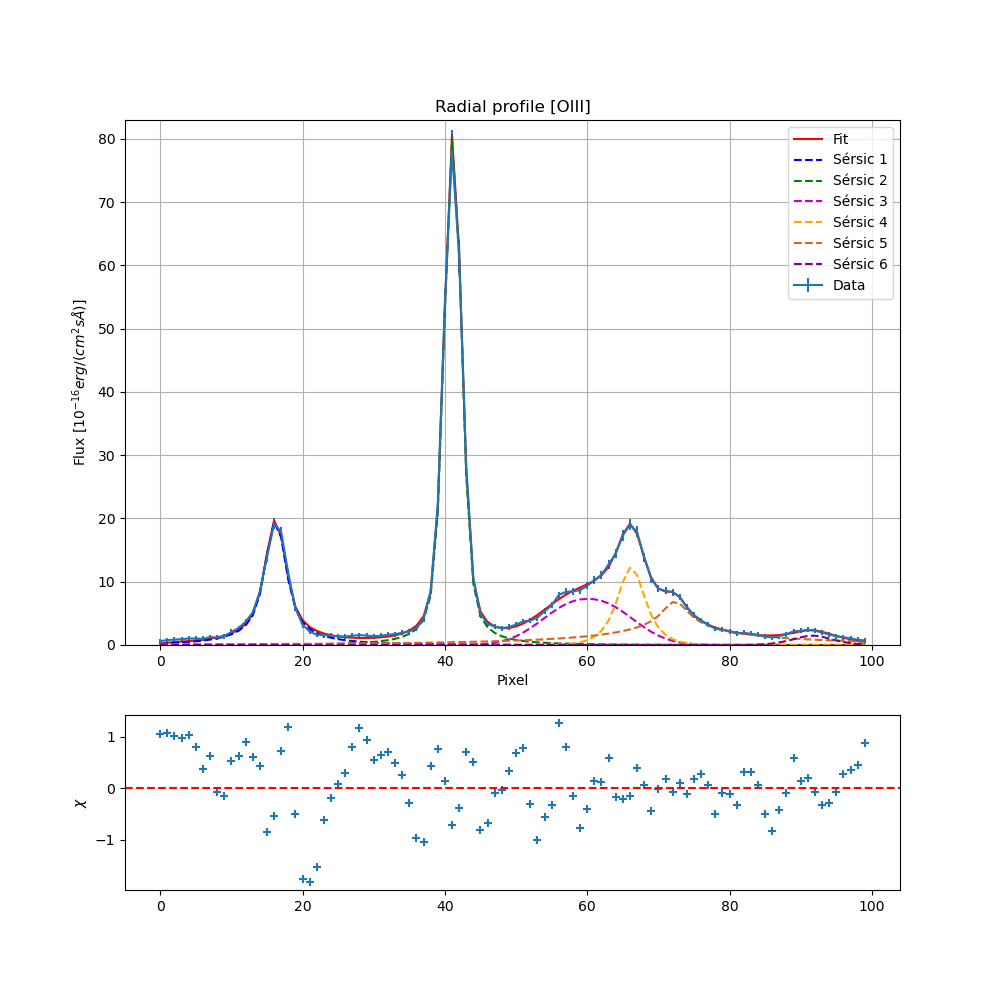

In [42]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [53]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

In [ ]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

In [ ]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

In [ ]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [ ]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

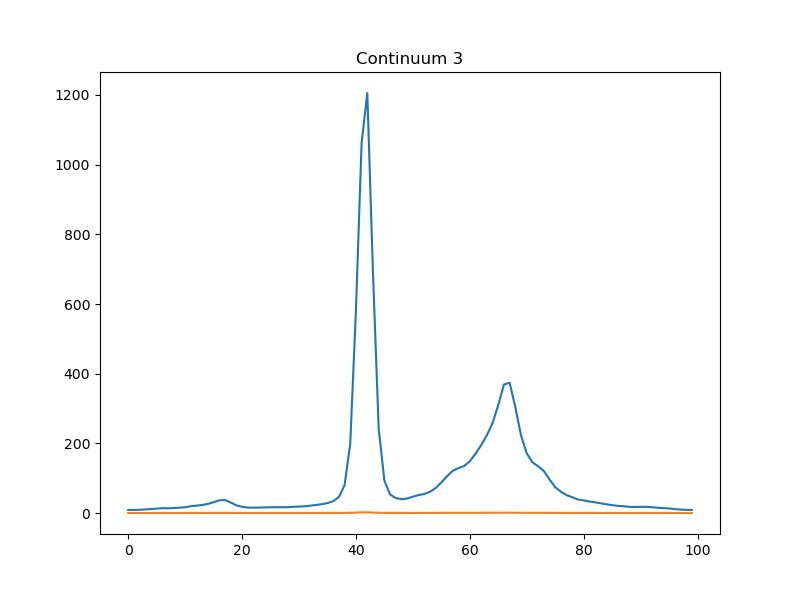

In [10]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [ ]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

In [ ]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [ ]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

In [ ]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [ ]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

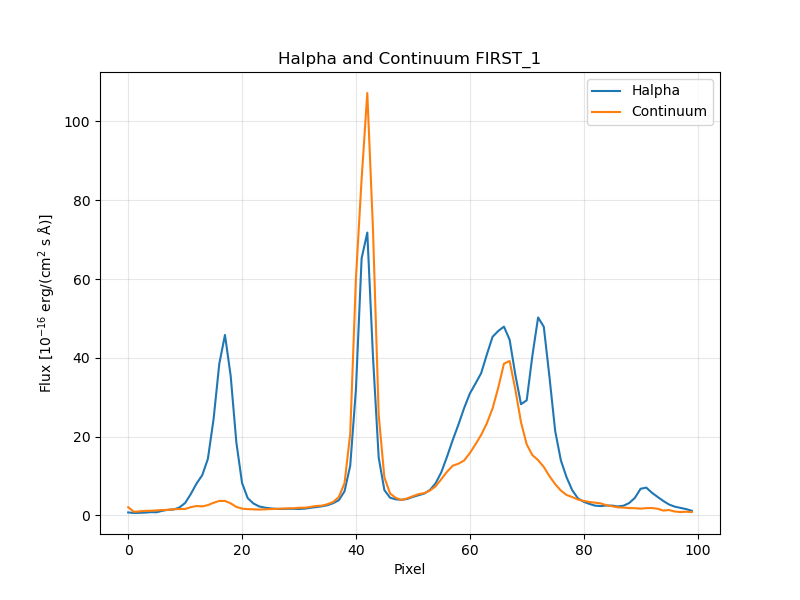

In [23]:
mask_continuum_3 = (wv > 6670)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum FIRST_1')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_FIRST_1')